# EX 4 – EX 4B – Experiment_4B_Baseball.ipynb
## DATA VISUALIZATION TECHNIQUES – BASEBALL DATABANK
**Aim:** Adapt the reference experiment to the Baseball Databank.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv("Batting.csv"); print("Shape:",df.shape); display(df.head())

Shape: (101332, 22)


,playerID,yearID,stint,teamID,lgID,G,AB,R,H,2B,3B,HR,RBI,SB,CS,BB,SO,IBB,HBP,SH,SF,GIDP
0,abercda01,1871,1,TRO,NaN,1,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
1,addybo01,1871,1,RC1,NaN,25,118.0,30.0,32.0,6.0,0.0,0.0,13.0,8.0,1.0,4.0,0.0,NaN,NaN,NaN,NaN,NaN
2,allisar01,1871,1,CL1,NaN,29,137.0,28.0,40.0,4.0,5.0,0.0,19.0,3.0,1.0,2.0,5.0,NaN,NaN,NaN,NaN,NaN
3,allisdo01,1871,1,WS3,NaN,27,133.0,28.0,44.0,10.0,2.0,2.0,27.0,1.0,1.0,0.0,2.0,NaN,NaN,NaN,NaN,NaN
4,ansonca01,1871,1,RC1,NaN,25,120.0,29.0,39.0,11.0,3.0,0.0,16.0,6.0,2.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN


In [2]:
display(df[["yearID","G","AB","R","H","HR","RBI","BB","SO"]].describe().round(2))

,yearID,G,AB,R,H,HR,RBI,BB,SO
count,101332.00,101332.00,96183.00,96183.00,96183.00,96183.00,95759.00,96183.00,88345.00
mean,1963.51,51.40,149.97,19.89,39.26,2.95,17.97,13.81,21.63
std,38.63,47.15,186.56,28.67,53.31,6.41,26.76,21.09,28.43
min,1871.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1933.00,13.00,7.00,0.00,1.00,0.00,0.00,0.00,2.00
50%,1972.00,34.00,57.00,5.00,11.00,0.00,4.00,3.00,10.00
75%,1997.00,80.25,251.00,30.00,63.00,3.00,27.00,20.00,30.00
max,2015.00,165.00,716.00,192.00,262.00,73.00,191.00,232.00,223.00


In [3]:
filtered=df[(df.yearID>=2000)&(df.R>=100)]; display(filtered[["yearID","playerID","teamID","R","H","HR","RBI"]].head(15))

,yearID,playerID,teamID,R,H,HR,RBI
79251,2000,abreubo01,PHI,103.0,182.0,25.0,79.0
79260,2000,alfoned01,NYN,109.0,176.0,25.0,94.0
79267,2000,alomaro01,CLE,111.0,189.0,19.0,89.0
79303,2000,bagweje01,HOU,152.0,183.0,47.0,132.0
79344,2000,benarma01,SFN,102.0,147.0,12.0,55.0
79375,2000,bondsba01,SFN,129.0,147.0,49.0,106.0
79455,2000,castilu01,FLO,101.0,180.0,2.0,17.0
79473,2000,cirilje01,COL,111.0,195.0,11.0,115.0
79533,2000,damonjo01,KCA,136.0,214.0,16.0,88.0
79548,2000,delgaca01,TOR,115.0,196.0,41.0,137.0


In [4]:
display(df.groupby("teamID")["R"].sum().sort_values(ascending=False).head(10))

teamID
CHN    96003.0
PHI    89959.0
PIT    88658.0
SLN    86003.0
CIN    85970.0
NYA    85715.0
BOS    83309.0
DET    83222.0
CLE    81116.0
CHA    78221.0
Name: R, dtype: float64

In [5]:
display(df.groupby("yearID")["R"].sum().tail(15))

yearID
2001    23199.0
2002    22408.0
2003    22978.0
2004    23376.0
2005    22325.0
2006    23599.0
2007    23322.0
2008    22585.0
2009    22419.0
2010    21308.0
2011    20808.0
2012    21017.0
2013    20255.0
2014    19761.0
2015    20647.0
Name: R, dtype: float64

In [6]:
display(df[["G","AB","R","H","HR","RBI","BB","SO"]].corr().round(2))

,G,AB,R,H,HR,RBI,BB,SO
G,1.00,0.95,0.89,0.93,0.66,0.87,0.84,0.80
AB,0.95,1.00,0.95,0.99,0.69,0.92,0.87,0.82
R,0.89,0.95,1.00,0.97,0.72,0.92,0.89,0.77
H,0.93,0.99,0.97,1.00,0.70,0.93,0.86,0.78
HR,0.66,0.69,0.72,0.70,1.00,0.83,0.73,0.79
RBI,0.87,0.92,0.92,0.93,0.83,1.00,0.85,0.79
BB,0.84,0.87,0.89,0.86,0.73,0.85,1.00,0.77
SO,0.80,0.82,0.77,0.78,0.79,0.79,0.77,1.00


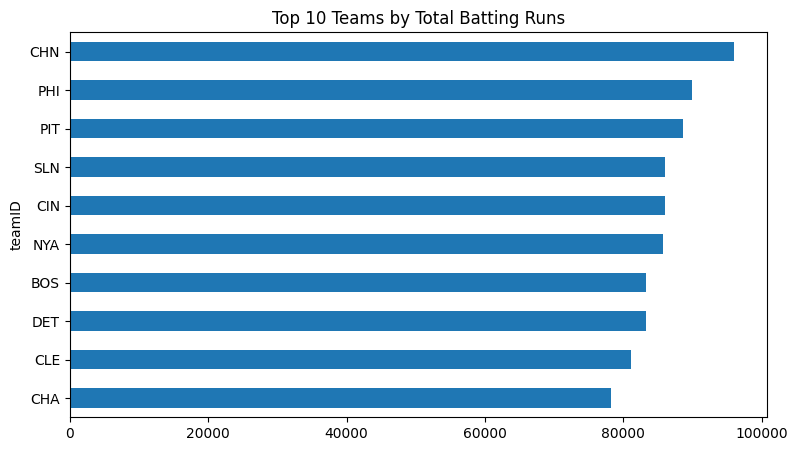

In [7]:
team=df.groupby("teamID")["R"].sum().nlargest(10).sort_values(); plt.figure(figsize=(9,5)); team.plot(kind="barh"); plt.title("Top 10 Teams by Total Batting Runs"); plt.show()

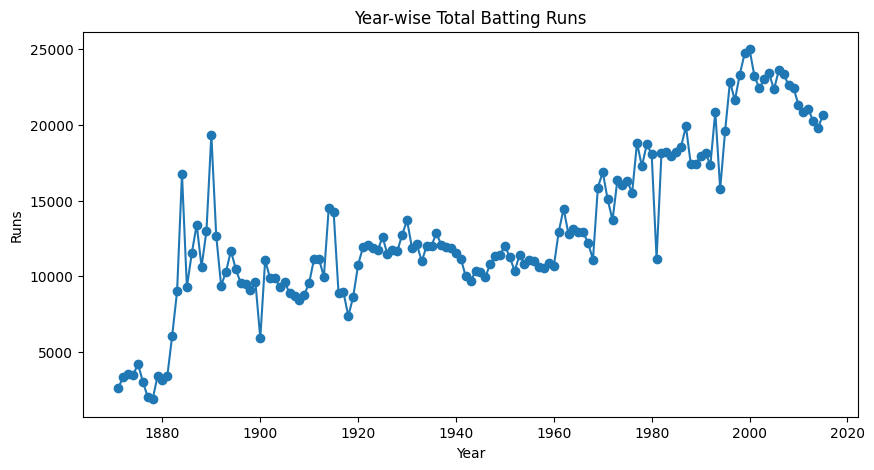

In [8]:
year=df.groupby("yearID")["R"].sum(); plt.figure(figsize=(10,5)); plt.plot(year.index,year.values,marker="o"); plt.title("Year-wise Total Batting Runs"); plt.xlabel("Year"); plt.ylabel("Runs"); plt.show()

          yearID          G        AB         R         H        HR       RBI        BB        SO
count  101332.00  101332.00  96183.00  96183.00  96183.00  96183.00  95759.00  96183.00  88345.00
mean     1963.51      51.40    149.97     19.89     39.26      2.95     17.97     13.81     21.63
std        38.63      47.15    186.56     28.67     53.31      6.41     26.76     21.09     28.43
min      1871.00       0.00      0.00      0.00      0.00      0.00      0.00      0.00      0.00
25%      1933.00      13.00      7.00      0.00      1.00      0.00      0.00      0.00      2.00
50%      1972.00      34.00     57.00      5.00     11.00      0.00      4.00      3.00     10.00
75%      1997.00      80.25    251.00     30.00     63.00      3.00     27.00     20.00     30.00
max      2015.00     165.00    716.00    192.00    262.00     73.00    191.00    232.00    223.00

teamID
CHN    96003.0
PHI    89959.0
PIT    88658.0
SLN    86003.0
CIN    85970.0
NYA    85715.0
BOS    83309.0
DET    83222.0
CLE    81116.0
CHA    78221.0

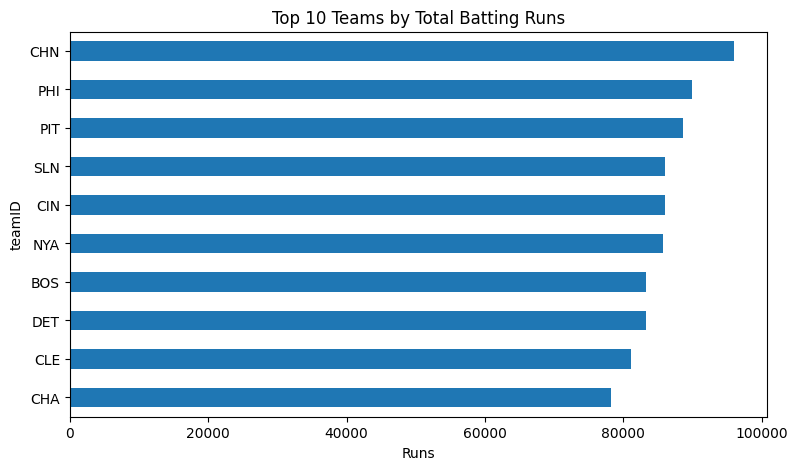

        G    AB     R     H    HR   RBI    BB    SO
G    1.00  0.95  0.89  0.93  0.66  0.87  0.84  0.80
AB   0.95  1.00  0.95  0.99  0.69  0.92  0.87  0.82
R    0.89  0.95  1.00  0.97  0.72  0.92  0.89  0.77
H    0.93  0.99  0.97  1.00  0.70  0.93  0.86  0.78
HR   0.66  0.69  0.72  0.70  1.00  0.83  0.73  0.79
RBI  0.87  0.92  0.92  0.93  0.83  1.00  0.85  0.79
BB   0.84  0.87  0.89  0.86  0.73  0.85  1.00  0.77
SO   0.80  0.82  0.77  0.78  0.79  0.79  0.77  1.00

In [1]:
# Saved output generated from the supplied Baseball Databank.
# Run Runtime → Run all in Colab to regenerate.